In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
import pandas as pd
import pickle
import data_processing as dp
import glob

In [3]:
def gaussian(x, *p):
	A, mu, variance = p
	return A*np.exp(-(x-mu)**2/(2.*variance))
	
def iterative_gaussian_fit(bincount, data, core_width=1.5, tol=0.1):
	gaussians = []
	coeffs = []

	hist_data, bin_edges = np.histogram(data,bins=bincount)

	# gaussian fit to entire range
	bin_ctrs = (bin_edges[:-1] + bin_edges[1:]) / 2
	initial_coeff_guess = [np.max(hist_data), bin_ctrs[np.argmax(hist_data)], np.std(data)**2]
	coeff, coeff_cov = curve_fit(gaussian, bin_ctrs, hist_data, p0=initial_coeff_guess)
	coeff_err = np.sqrt(np.diag(coeff_cov))

	gaussian_xvals = np.linspace(bin_ctrs[0], bin_ctrs[-1], 1000)
	gaussians.append([gaussian_xvals, gaussian(gaussian_xvals, *coeff)])
	coeffs.append(coeff)

	iters = 0
	converged = False

	_, prev_mu, prev_variance = initial_coeff_guess
	_, mu, variance = coeff

	# reduce range until the tolerance is satisfied
	while iters < 100:
		iters += 1
		mask = (mu - core_width * np.sqrt(variance) < bin_ctrs) & (bin_ctrs < mu + core_width * np.sqrt(variance)) #+-core_width Sigma
		masked_data = hist_data[mask]
		if len(masked_data) < 3: break
		masked_bin_ctrs = bin_ctrs[mask]

		# print(f"bin centers {masked_bin_ctrs}, data {masked_data}, coeff {coeff}")
		coeff, _ = curve_fit(gaussian, masked_bin_ctrs, masked_data, p0=coeff)
		prev_mu, prev_variance = mu, variance
		_, mu, variance = coeff
		if variance <= 0: print("hold up!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
		if abs((mu - prev_mu) / prev_mu) < tol and abs((variance - prev_variance) / prev_variance) < tol:
			# print(f"final iteration: mu={mu}, prev_mu={prev_mu}, sigma={sigma}. prev_sigma={prev_sigma}")
			converged = True
			break

	if not converged: print(f"Iterative Gaussian fit never converged. The algorithm may be oscillating between two fits that are not within the tolerance.")
	# print(mu-core_width*np.sqrt(variance), mu+core_width*np.sqrt(variance),"ok so  ",gaussian_xvals[1]-gaussian_xvals[0], 2*core_width*np.sqrt(variance))
	final_mask = (mu - core_width * np.sqrt(variance) < gaussian_xvals) & (gaussian_xvals < mu + core_width * np.sqrt(variance))

	return gaussian_xvals, final_mask, coeff, coeff_err

def fit_energy_resolution(x, p0, p1):
	return np.sqrt(p0 + p1/x)

def fit_energy_resolution_quad(x, C, A, B):
	return np.sqrt(C**2 + A**2/x + B**2/(x**2))


In [4]:
# #Data path and data containers
# noiseEnergy = 0
# eResSample = "Pion_E3"
# species = eResSample.split("_")[0]
# sample = "eRes"
# particleEnergy = eResSample.split("E")[1]

# print(species, particleEnergy)
# file_pattern = f"/users/6/vadna042/hgcalml/hgcal_minimal_eval_example/output/{eResSample}/*"
# file_limit = 2000
# files = glob.glob(file_pattern)[:file_limit]
# print(len(files))

# true_cluster = np.empty(file_limit, dtype=object)
# final_pred_hits = np.empty(file_limit, dtype=object)
# energy_true = np.empty(file_limit, dtype=object)
# energy_reco = np.empty(file_limit, dtype=object)

# for i in range(len(files)):
#     data, _, pass_noise_filter, out_gravnet = dp.load_data(files[i])
#     true_cluster[i] = np.asarray(data.y)
#     final_pred_hits[i] = np.asarray(dp.process_gravnet(pass_noise_filter, out_gravnet))
#     energy_true[i] = data.x[:,0][true_cluster[i]==1]
#     energy_reco[i] = data.x[:,0][final_pred_hits[i] > 0]

# layer_positions = np.loadtxt("unique_z.txt")

# # true_cluster = np.array([ data[i].y for i in range(file_limit)], dtype=object) # real hits==1
# # final_pred_hits = np.array([ dp.process_gravnet(pass_noise_filter[i], out_gravnet[i]) for i in range(file_limit)], dtype=object) #real clusterHits>0

# # energy_true = np.array([ data[i].x[:,0][true_cluster[i]==1] for i in range(file_limit) ], dtype=object)
# # energy_reco = np.array([ data[i].x[:,0][final_pred_hits[i] > 0] for i in range(file_limit) ], dtype=object)

# # print(len(energy_true))

# e_true_summed = np.asarray([np.sum(np.asarray(energy_true[i])) for i in range(file_limit)])
# e_reco_summed = np.asarray([np.sum(np.asarray(energy_reco[i])) for i in range(file_limit)])


In [ ]:
def plotdiffs(species, particleEnergy, noiseEnergy, e_reco, e_true, bins):
    a = e_reco-e_true
    a = a[(a > -0.5)]
    # hist_data, bin_edges = np.histogram(a,bins=reco_bins)
    gaussian_xvals, final_mask, coeff, coeff_err = iterative_gaussian_fit(bins, a, core_width = 1.5, tol = 0.10)
    fig, ax = plt.subplots()
    ax.hist(a,bins=bins, label=f"{species} {particleEnergy}GeV, noise: {noiseEnergy}")
    ax.plot(gaussian_xvals, gaussian(gaussian_xvals,*coeff), "k--", linewidth=1, label=f"Fit Mean: {coeff[1]:.3e}GeV\nFit Std: {(coeff[2])**0.5:.3e}GeV", alpha=0.8)
    ax.plot(gaussian_xvals[final_mask], gaussian(gaussian_xvals[final_mask],*coeff), "k-", linewidth=2, alpha=1, label="Core")
    # ax.set_xlim(-1.5,1.5)
    ax.set_title("Summed Energy Difference (Pred-True)")
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel("Count")
    ax.legend()
    plt.show()

    return coeff, coeff_err

def ploteRes(species, particleEnergy, noiseEnergy, e_reco, bins):
    b = e_reco
    # b = b[b < 10]
    gaussian_xvals2, final_mask2, coeff2, coeff_err2 = iterative_gaussian_fit(bins, b, core_width = 1.5, tol = 0.10)
    fig2, ax2 = plt.subplots()
    ax2.hist(b,bins=bins, label=f"{species} {particleEnergy}GeV, noise: {noiseEnergy}")
    ax2.plot(gaussian_xvals2, gaussian(gaussian_xvals2,*coeff2), "k--", linewidth=1, label=f"Fit Mean: {coeff2[1]:.3e}GeV\nFit Std: {(coeff2[2])**0.5:.3e}GeV", alpha=0.8)
    ax2.plot(gaussian_xvals2[final_mask2], gaussian(gaussian_xvals2[final_mask2],*coeff2), "k-", linewidth=2, alpha=1, label="Core")
    # ax.set_xlim(-1.5,1.5)
    ax2.set_title("Summed Energy (Pred)")
    ax2.set_xlabel("Energy (GeV)")
    ax2.set_ylabel("Count")
    ax2.legend()
    plt.show()
    return coeff2, coeff_err2

def eResFitted(eResSample):
    species, particleEnergy, noiseEnergy = eResSample.split("_")
    sample = "eRes"
    particleEnergy = int(particleEnergy[1:])
    if noiseEnergy=="1-5": #How did we get here? Switch maybe?
        noiseEnergy=1.5
    else:
        noiseEnergy=int(noiseEnergy)

    with open(f"eres_processed/{eResSample}.pkl","rb") as file:
        e_true_summed, e_reco_summed = pickle.load(file)

    diff_bins = 100
    bins = 100
    diff_coeff, diff_coeff_err = plotdiffs(species, particleEnergy, noiseEnergy, e_reco_summed, e_true_summed, bins=diff_bins)
    coeff, coeff_err = ploteRes(species, particleEnergy, noiseEnergy, e_reco_summed, bins=bins)

    d = pd.DataFrame({"species": species, \
        "sample":sample, \
        "ptdEn":particleEnergy, \
        "noise":noiseEnergy, \
        "coeff_amp":coeff[0], \
        "coeff_mean":coeff[1], \
        "coeff_std":coeff[2]**0.5, \
        "coeff_amp_err":coeff_err[0], \
        "coeff_mean_err":coeff_err[1], \
        "coeff_std_err":coeff_err[2]**0.5, \
        "diff_coeff_amp":diff_coeff[0], \
        "diff_coeff_mean":diff_coeff[1], \
        "diff_coeff_std":diff_coeff[2]**0.5, \
        "diff_coeff_amp_err":diff_coeff_err[0], \
        "diff_coeff_mean_err":diff_coeff_err[1], \
        "diff_coeff_std_err":diff_coeff_err[2]**0.5, \
        "bins":bins,
        "diff_bins":diff_bins}, dtype=object, index=[0])
    
    return d

['Tau_E2_0', 'Tau_E2_1-5', 'Tau_E2_2', 'Tau_E2_5', 'Tau_E2_10', 'Tau_E3_0', 'Tau_E3_1-5', 'Tau_E3_2', 'Tau_E3_5', 'Tau_E3_10', 'Tau_E5_0', 'Tau_E5_1-5', 'Tau_E5_2', 'Tau_E5_5', 'Tau_E5_10', 'Tau_E10_0', 'Tau_E10_1-5', 'Tau_E10_2', 'Tau_E10_5', 'Tau_E10_10', 'Tau_E25_0', 'Tau_E25_1-5', 'Tau_E25_2', 'Tau_E25_5', 'Tau_E25_10', 'Tau_E50_0', 'Tau_E50_1-5', 'Tau_E50_2', 'Tau_E50_5', 'Tau_E50_10', 'Tau_E75_0', 'Tau_E75_1-5', 'Tau_E75_2', 'Tau_E75_5', 'Tau_E75_10', 'Tau_E100_0', 'Tau_E100_1-5', 'Tau_E100_2', 'Tau_E100_5', 'Tau_E100_10', 'Tau_E200_0', 'Tau_E200_1-5', 'Tau_E200_2', 'Tau_E200_5', 'Tau_E200_10', 'Tau_E300_0', 'Tau_E300_1-5', 'Tau_E300_2', 'Tau_E300_5', 'Tau_E300_10']


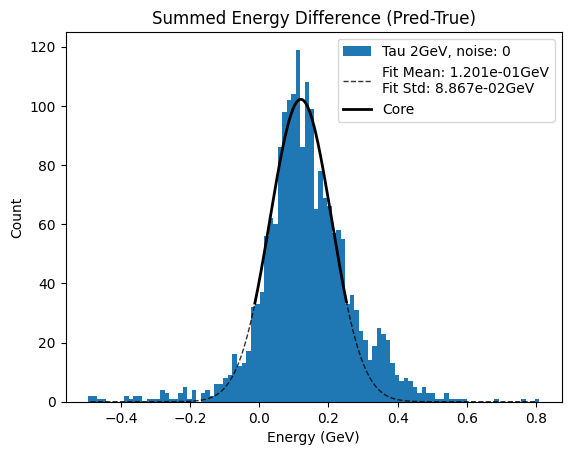

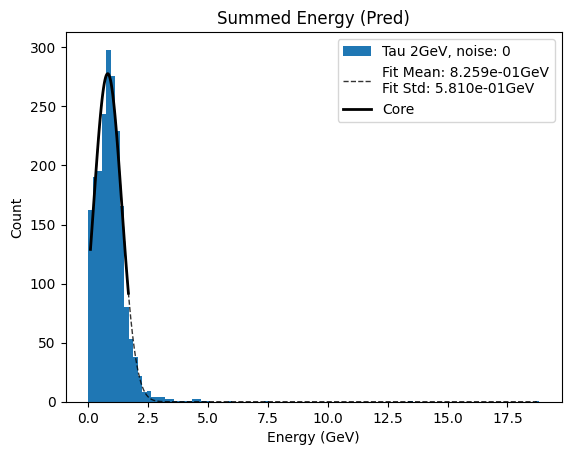

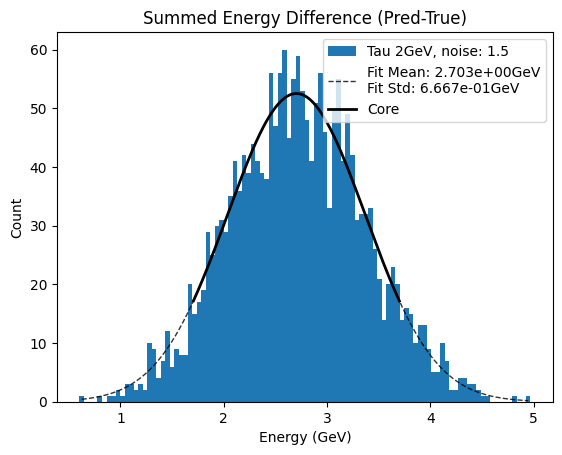

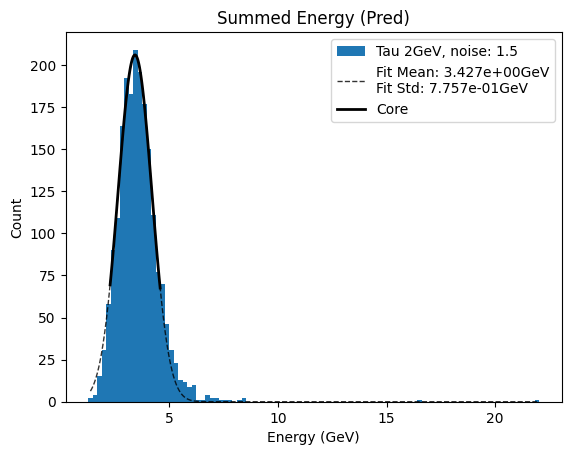

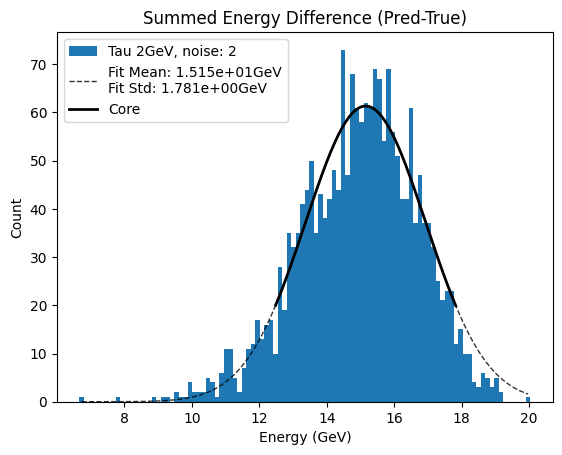

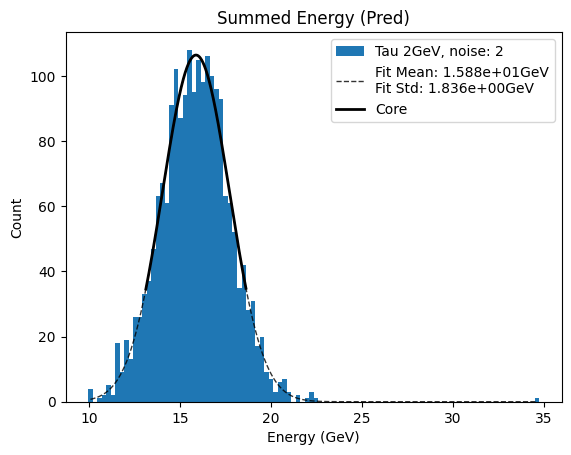

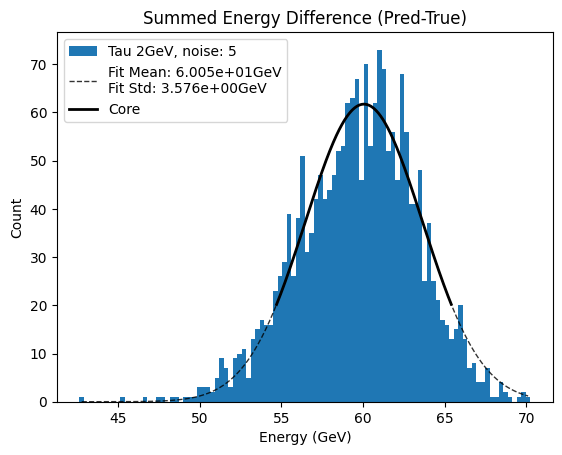

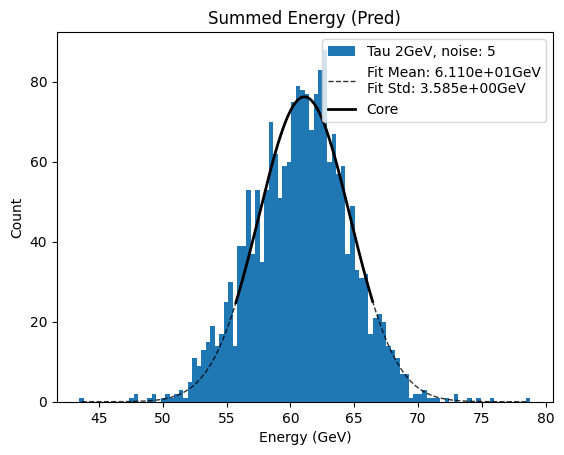

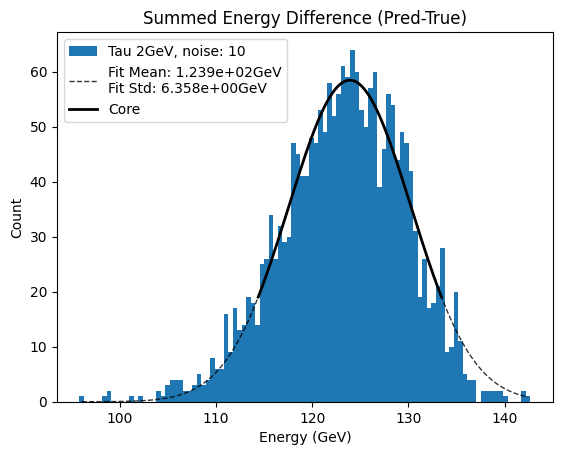

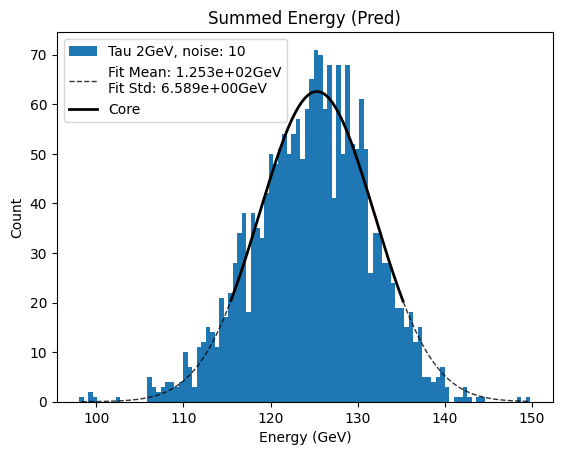

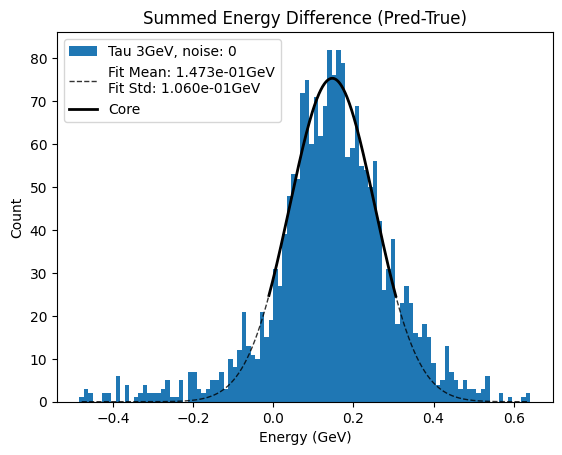

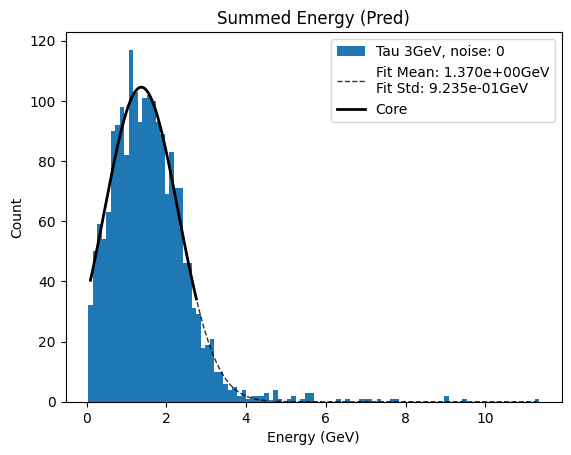

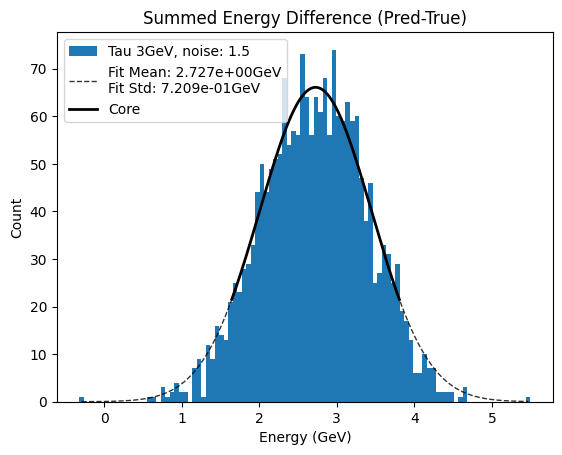

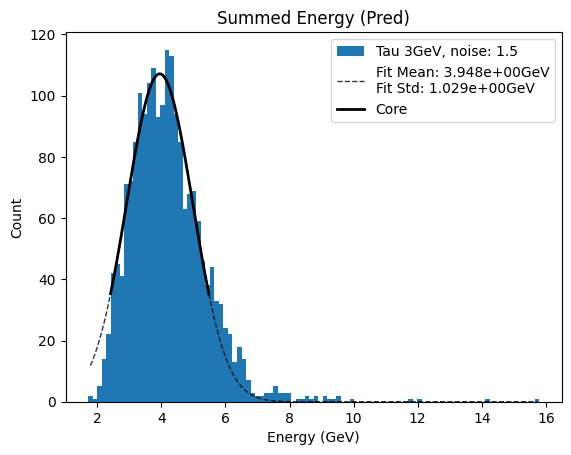

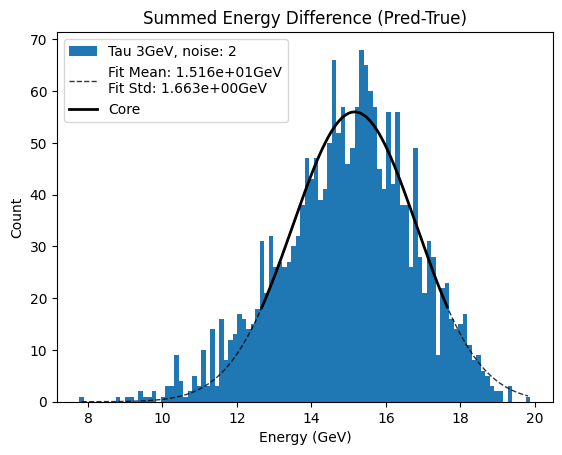

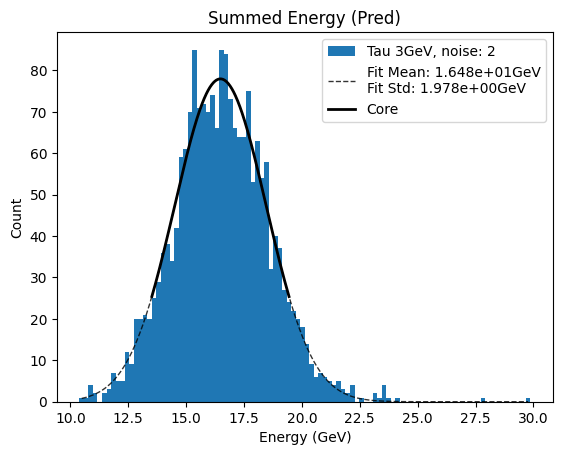

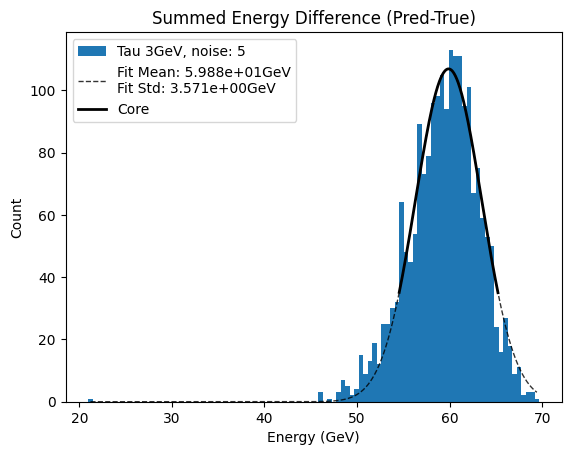

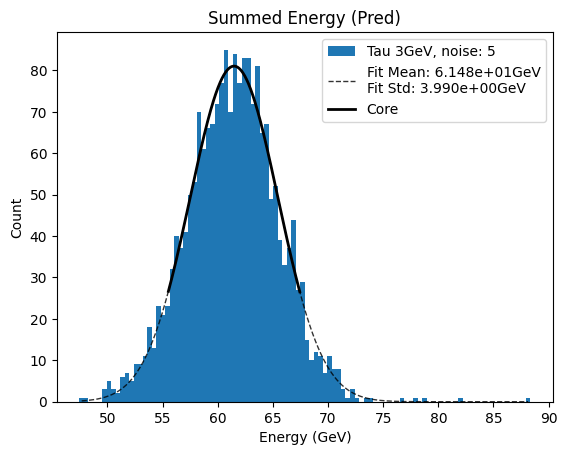

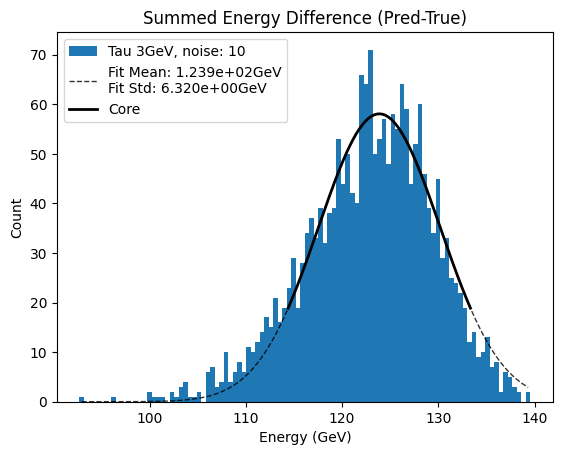

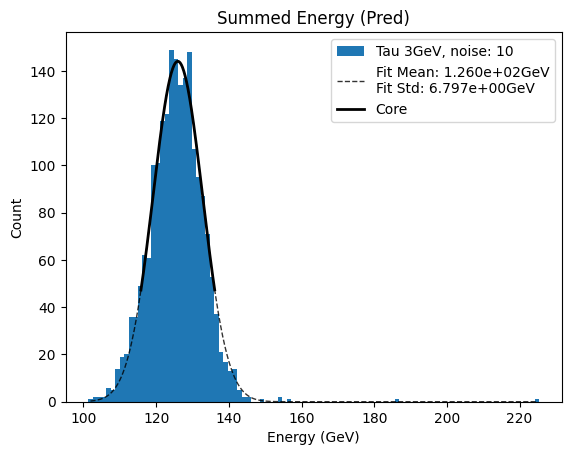

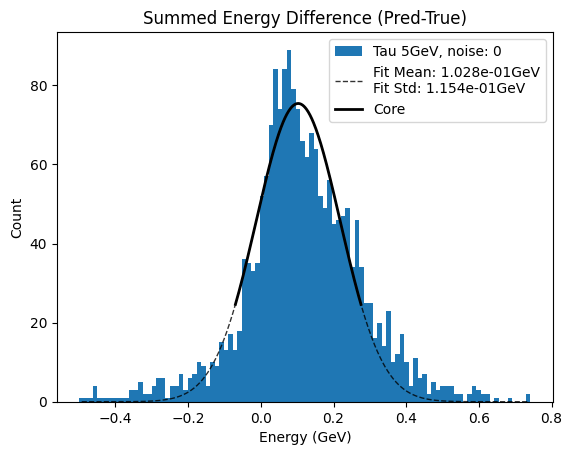

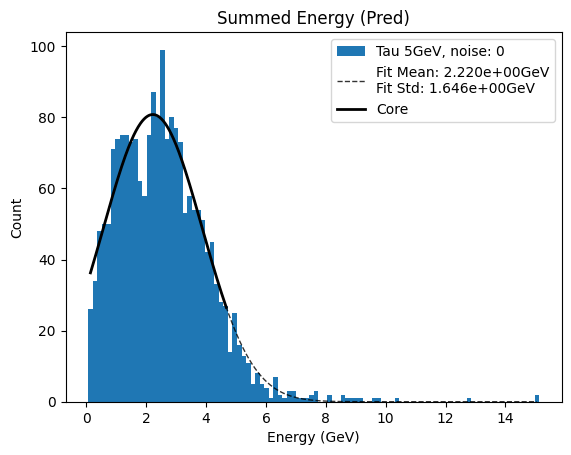

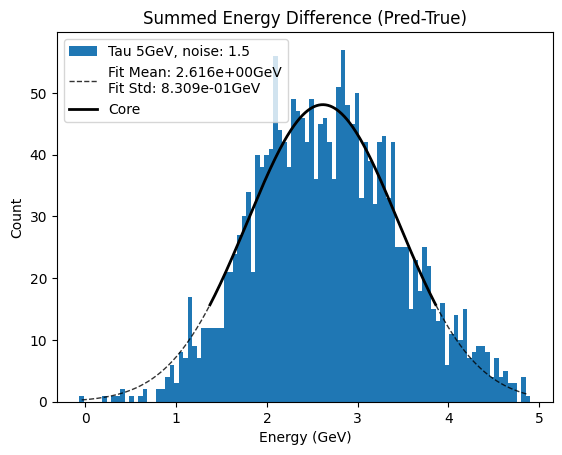

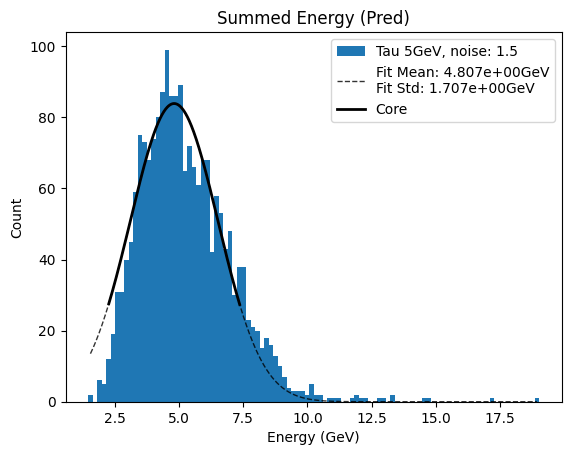

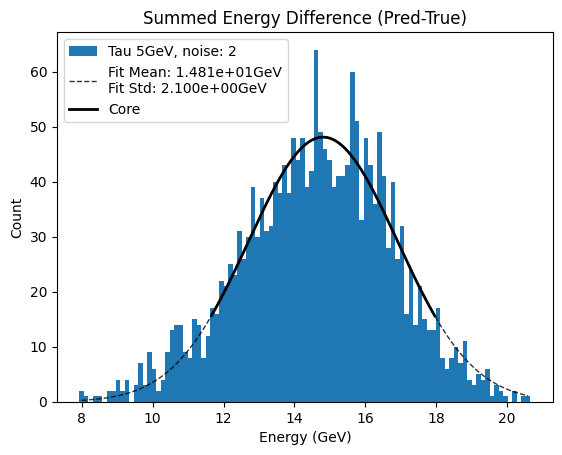

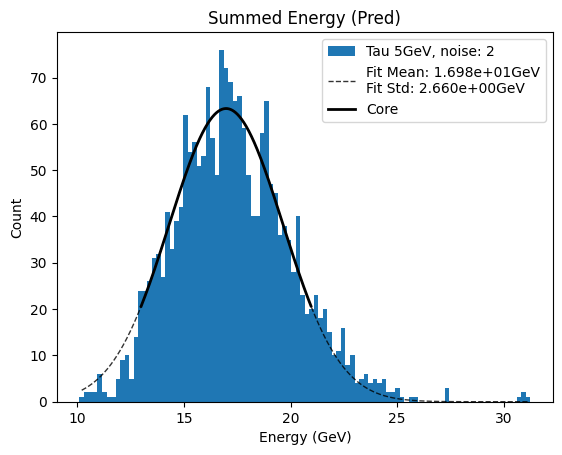

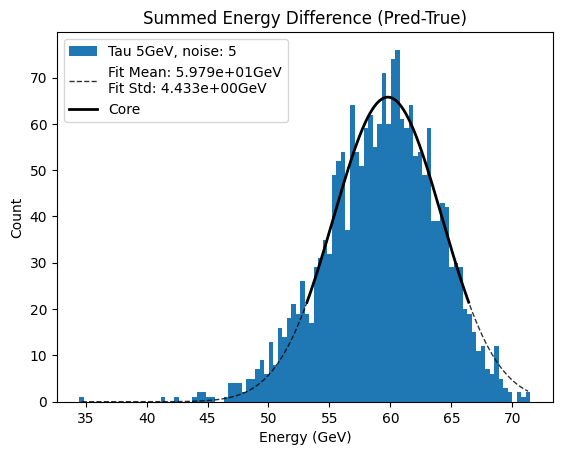

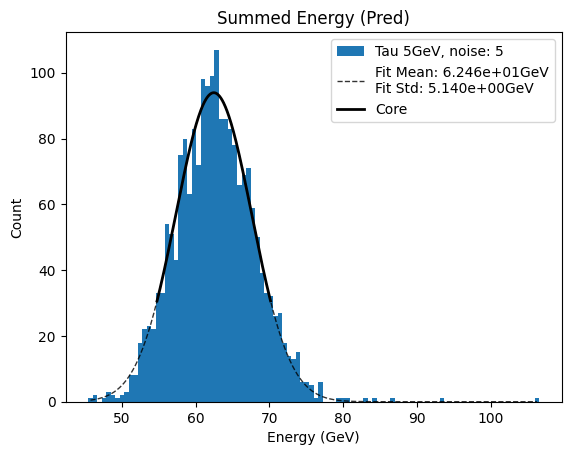

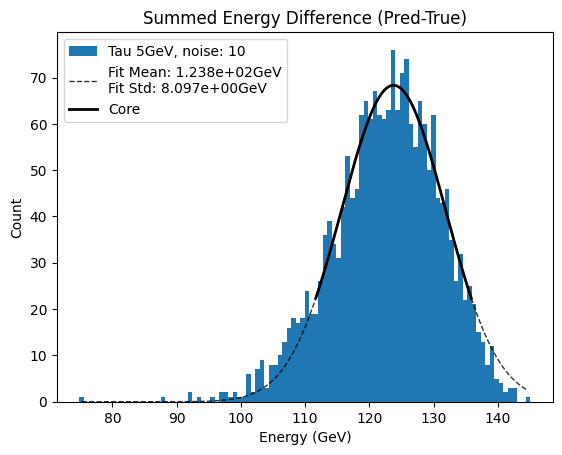

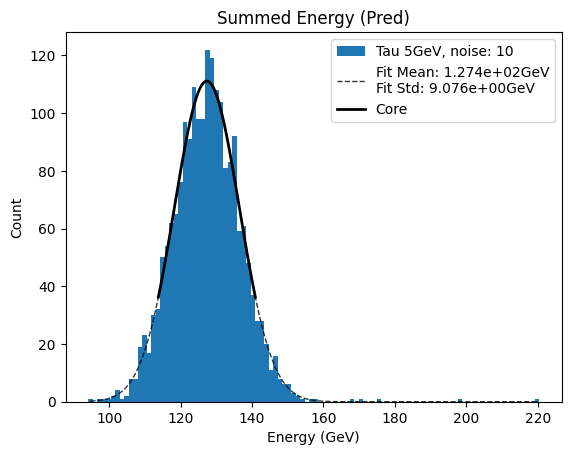

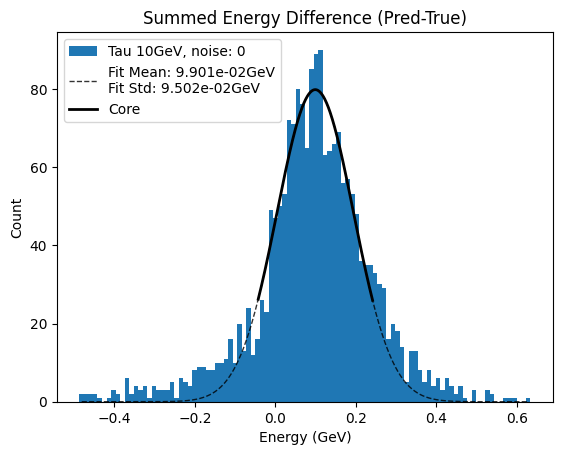

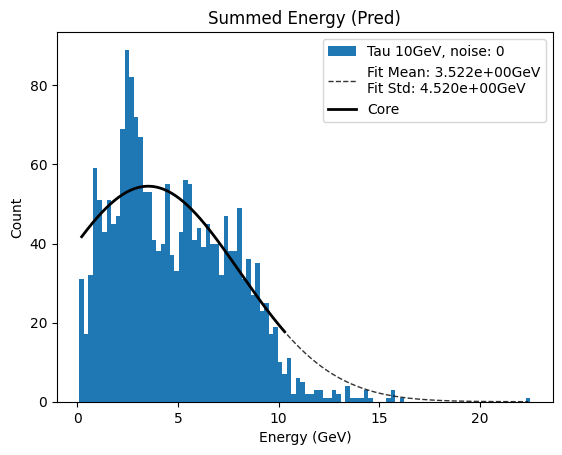

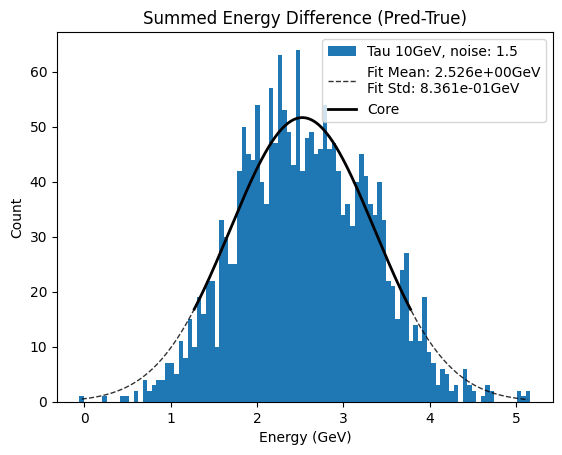

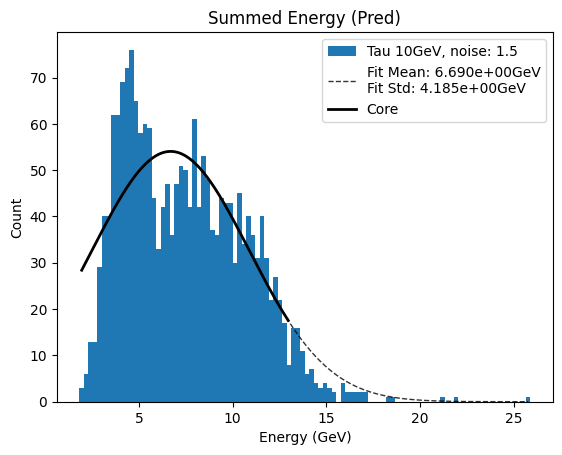

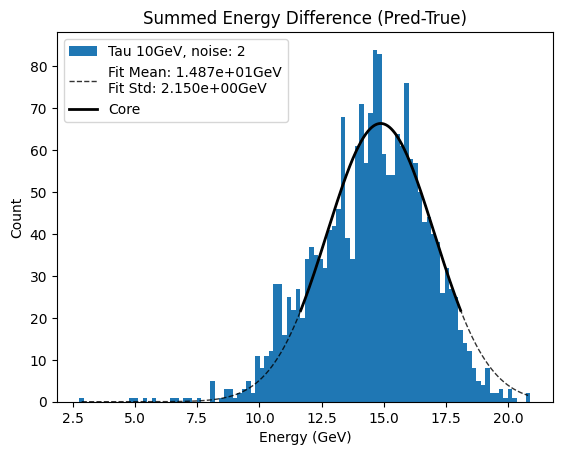

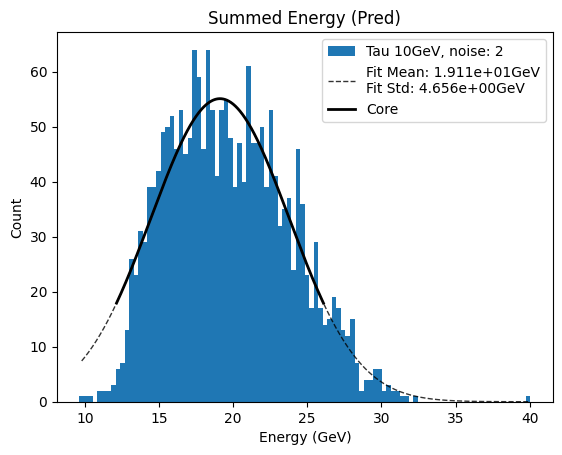

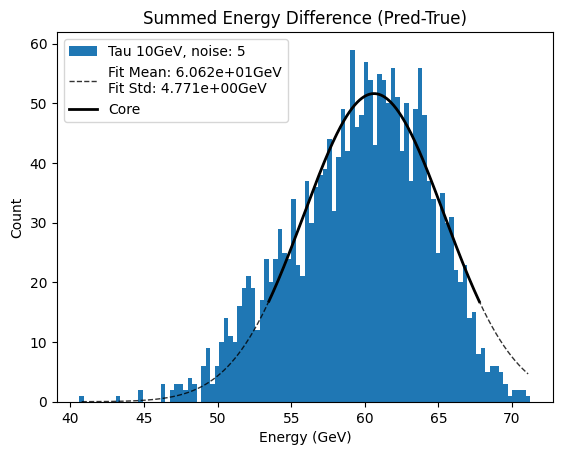

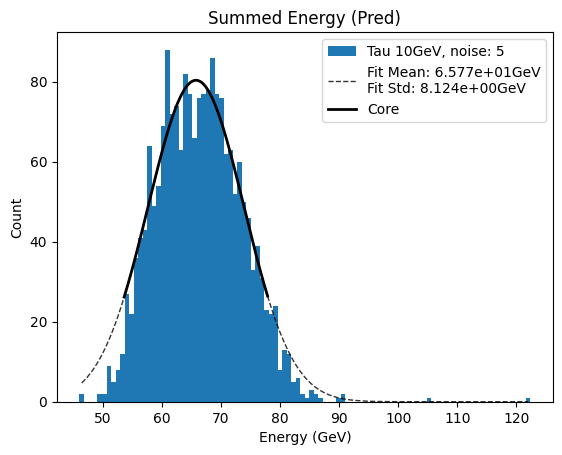

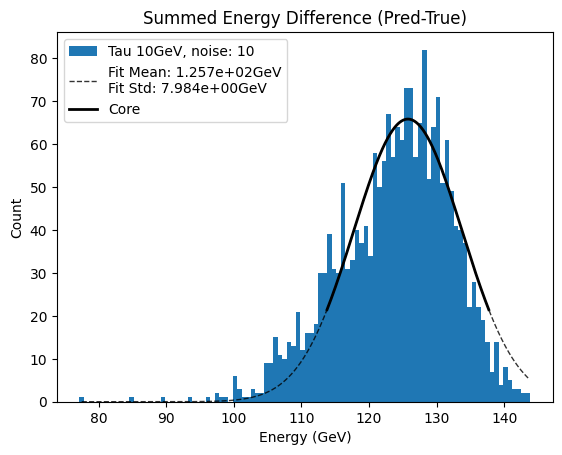

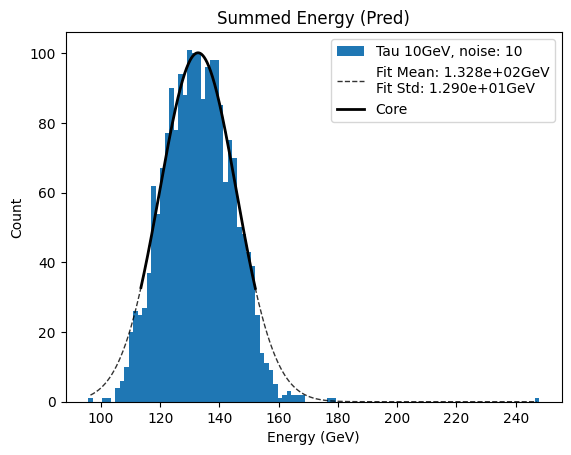

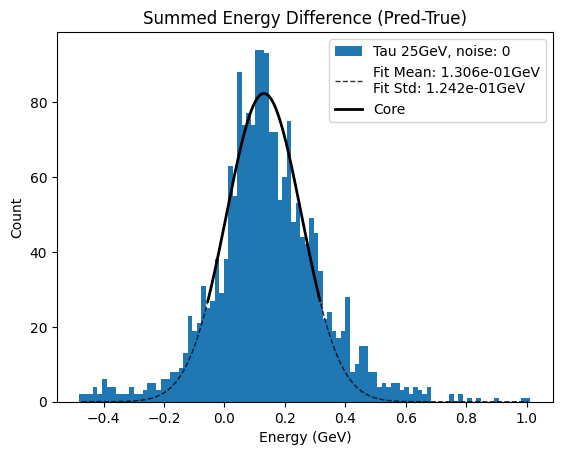

Iterative Gaussian fit never converged. The algorithm may be oscillating between two fits that are not within the tolerance.


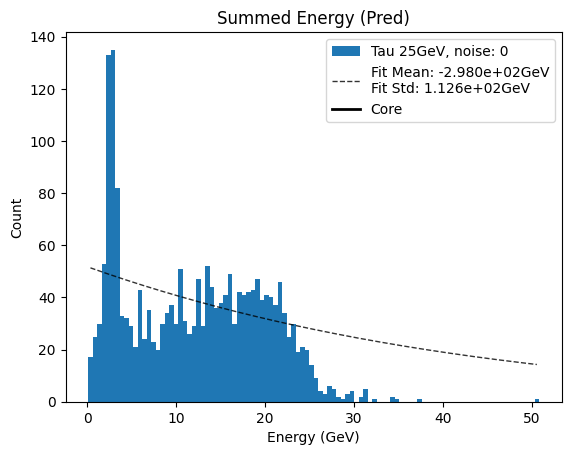

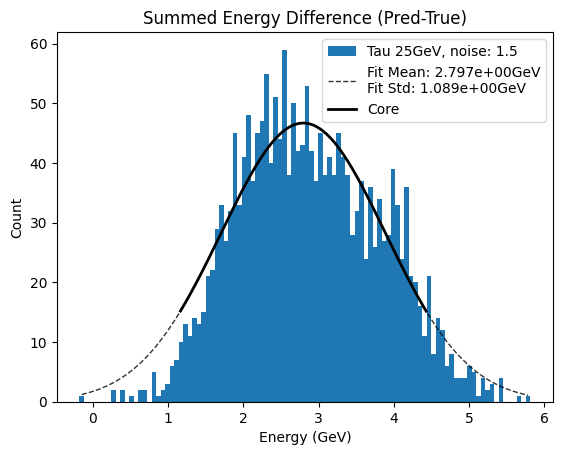

Iterative Gaussian fit never converged. The algorithm may be oscillating between two fits that are not within the tolerance.


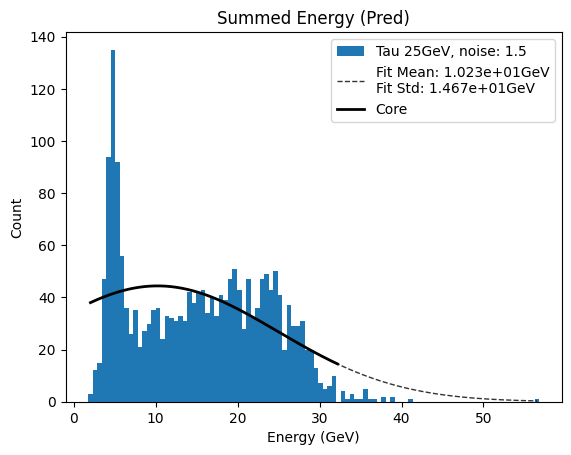

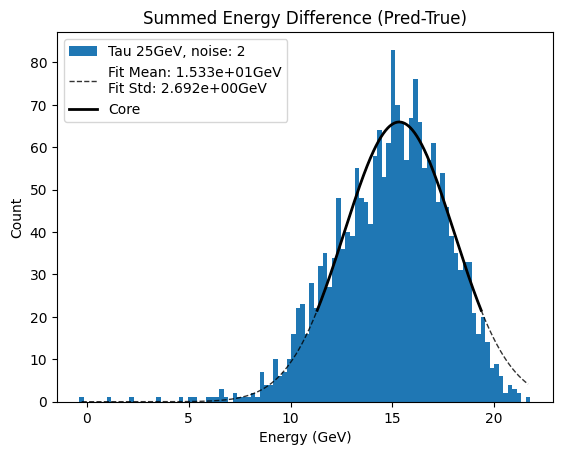

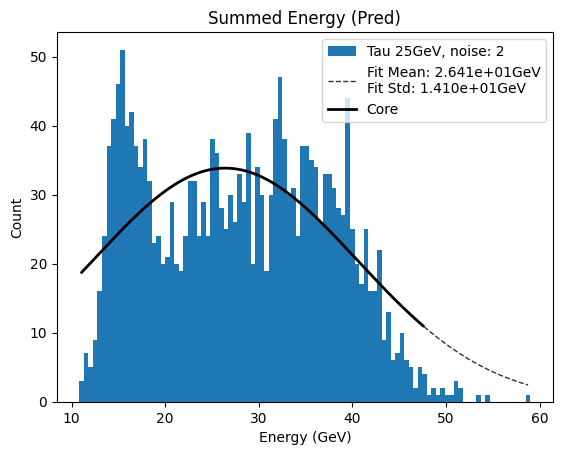

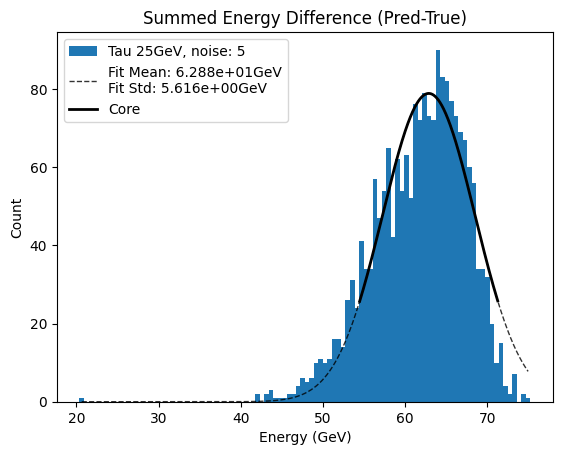

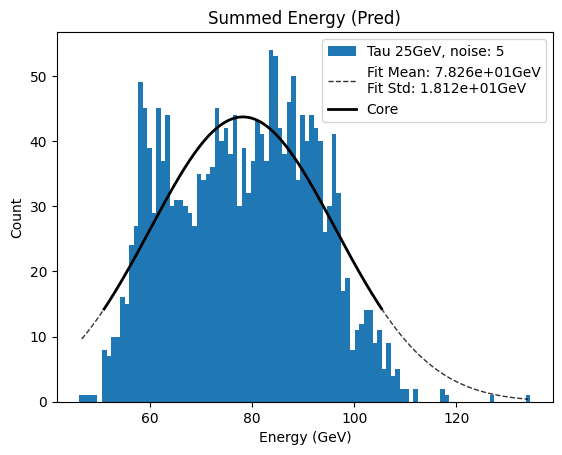

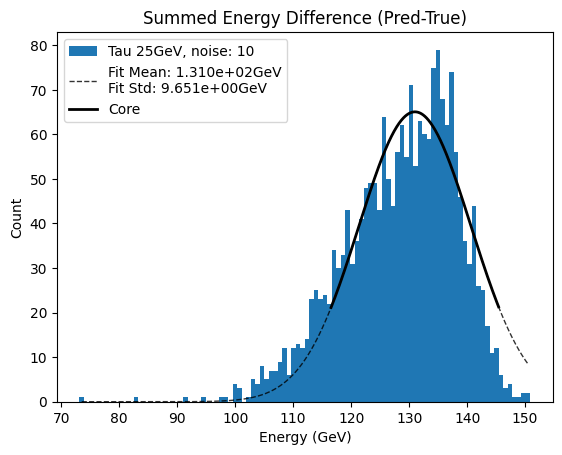

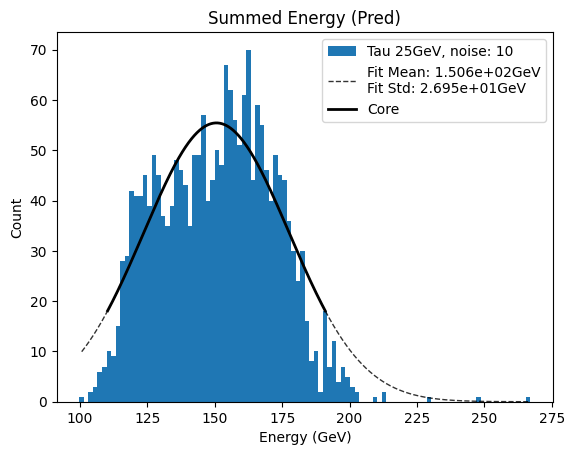

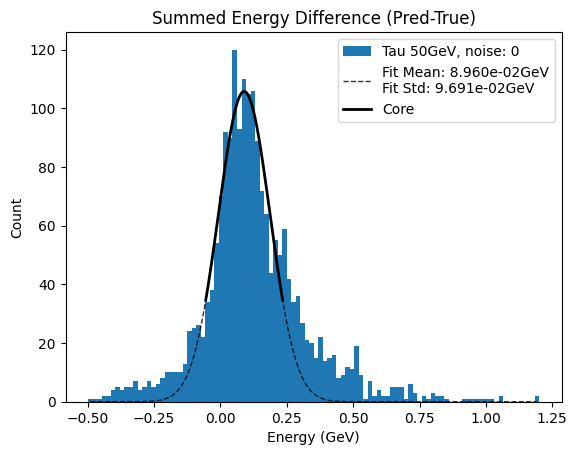

Iterative Gaussian fit never converged. The algorithm may be oscillating between two fits that are not within the tolerance.


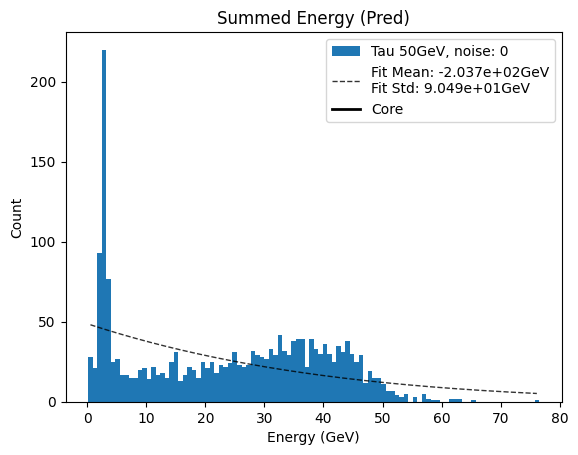

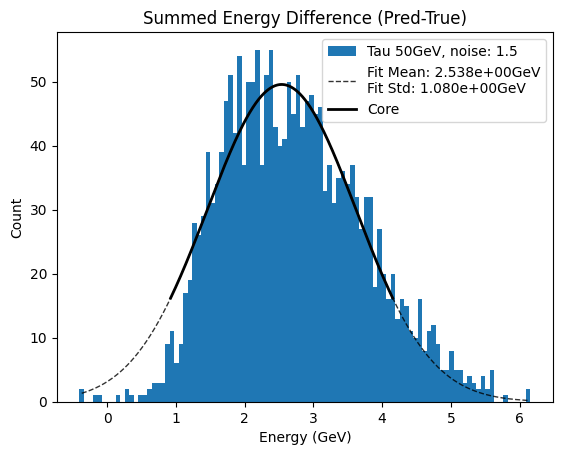

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

In [80]:
layer_positions = np.loadtxt("unique_z.txt")
namelist = []
for en in [2,3,5,10,25,50,75,100,200,300]:
    for noi in ["0","1-5","2","5","10"]:
        namelist.append(f"Tau_E{en}_{noi}")
print(namelist)
pdlist = list(map(eResFitted,namelist))


In [ ]:

with open("eres_processed/.moddedeRes.pkl",'rb') as file:
    d1 = pickle.load(file)

# print(d1)
# with open("eres_processed/.moddedeRes.pkl",'wb') as file:
#     pickle.dump(pd.concat([d1] + pdlist),file)

0


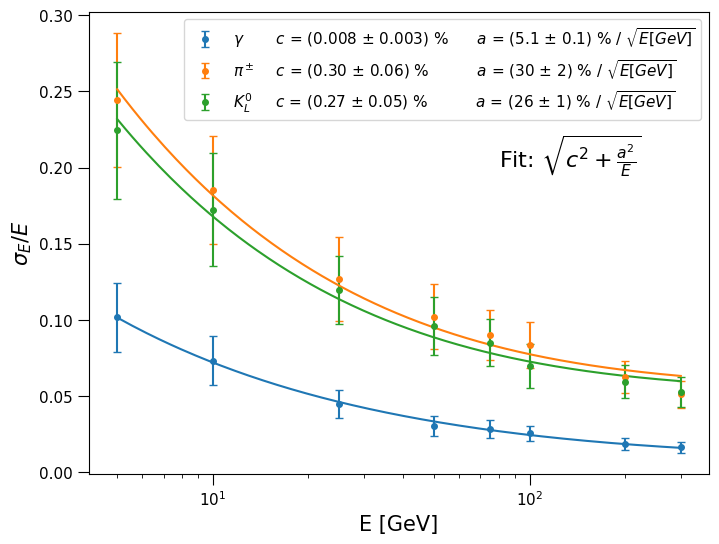

In [66]:
with open(".fulleRes.pkl",'rb') as file:
    d1 = pickle.load(file)

dGamma = d1.loc[d1["species"]=="Gamma"][2:]
Gamma_ens = np.asarray(dGamma["ptdEn"])
Gamma_sigs = np.asarray(dGamma["std"])

dPion = d1.loc[d1["species"]=="Pion"][2:]
Pion_ens = np.asarray(dPion["ptdEn"])
Pion_sigs = np.asarray(dPion["std"])

dKaon = d1.loc[d1["species"]=="Kaon"][2:]
Kaon_ens = np.asarray(dKaon["ptdEn"])
Kaon_sigs = np.asarray(dKaon["std"])



def fit3param(Gamma_ens, Gamma_sigs, Pion_ens, Pion_sigs, Kaon_ens, Kaon_sigs):
    
    ps_1x, ps_cov_1x = curve_fit(fit_energy_resolution_quad,Gamma_ens, Gamma_sigs/Gamma_ens, p0=[0.01, 0.22,0.11], bounds=([0,0,0],[1,1,10000]))
    ps_2x, ps_cov_2x = curve_fit(fit_energy_resolution_quad,Pion_ens, Pion_sigs/Pion_ens, p0=[0.05,0.62,0.72], bounds=([0,0,0],[1,1,10000]))
    ps_3x, ps_cov_3x = curve_fit(fit_energy_resolution_quad,Kaon_ens, Kaon_sigs/Kaon_ens, p0=[0.04,0.58,0.69], bounds=([0,0,0],[1,1,10000]))

    ps_err_1x = np.sqrt(np.diag(ps_cov_1x))
    ps_err_2x = np.sqrt(np.diag(ps_cov_2x))
    ps_err_3x = np.sqrt(np.diag(ps_cov_3x))

    print(ps_err_1x, ps_err_2x, ps_err_3x)

    plt.figure(figsize = [8,6])
    plt.errorbar(Gamma_ens,np.asarray(Gamma_sigs)/np.asarray(Gamma_ens), np.asarray(dGamma["std_err"])/np.asarray(Gamma_ens), fmt='o',markersize=4,linestyle = "none",capsize=3, color="tab:blue")
    plt.errorbar(Pion_ens,np.asarray(Pion_sigs)/np.asarray(Pion_ens), np.asarray(dPion["std_err"])/np.asarray(Pion_ens), fmt='o', markersize=4, linestyle = "none", capsize=3, color="tab:orange")
    plt.errorbar(Kaon_ens,np.asarray(Kaon_sigs)/np.asarray(Kaon_ens), np.asarray(dKaon["std_err"])/np.asarray(Kaon_ens), fmt='o', markersize=4, linestyle = "none", capsize=3, color="tab:green")

    plt.text(35,0.15,r"Fit: $\sqrt{c^2 + \frac{a^2}{E} + \frac{b^2}{E^2}}$")
    
    x_Gamma = np.linspace(Gamma_ens[0],Gamma_ens[-1],1000)
    x_Pion = np.linspace(Pion_ens[0], Pion_ens[-1],1000)
    x_Kaon = np.linspace(Kaon_ens[0], Kaon_ens[-1],1000)
    
    plt.xlabel("Energy [GeV]")
    plt.ylabel(r"$\sigma_E/E}$")
    plt.xscale("log")
    plt.title(f"Energy Resolution")
    plt.plot(x_Gamma,fit_energy_resolution_quad(x_Gamma,ps_1x[0],ps_1x[1],ps_1x[2]), label=f"Gamma $C$ = {ps_1x[0]:.4f} $\pm$ {ps_err_1x[0]:0.4f} \
            \n$A$ = {ps_1x[1]:.4f} $\pm$ {ps_err_1x[1]:0.4f}\
            \n$B$ = {abs(ps_1x[2]):.4f} $\pm$ {ps_err_1x[2]:0.4f}")
    plt.plot(x_Pion,fit_energy_resolution_quad(x_Pion,ps_2x[0],ps_2x[1],ps_2x[2]), label=f"Pion $C$ = {ps_2x[0]:.4f} $\pm$ {ps_err_2x[0]:0.4f} \
            \n$A$ = {ps_2x[1]:.4f} $\pm$ {ps_err_2x[1]:0.4f}\
            \n$B$ = {abs(ps_2x[2]):.4f} $\pm$ {ps_err_2x[2]:0.4f}")
    plt.plot(x_Kaon,fit_energy_resolution_quad(x_Kaon,ps_3x[0],ps_3x[1],ps_3x[2]), label=f"Kaon $C$ = {ps_3x[0]:.4f} $\pm$ {ps_err_3x[0]:0.4f} \
            \n$A$ = {ps_3x[1]:.4f} $\pm$ {ps_err_3x[1]:0.4f}\
            \n$B$ = {abs(ps_3x[2]):.4f} $\pm$ {ps_err_3x[2]:0.4f}")
    plt.legend()

def fit2param(Gamma_ens, Gamma_sigs, Pion_ens, Pion_sigs, Kaon_ens, Kaon_sigs):
    ps_1x, ps_cov_1x = curve_fit(fit_energy_resolution,Gamma_ens, Gamma_sigs/Gamma_ens, bounds=([0,0],[1,1]))
    ps_2x, ps_cov_2x = curve_fit(fit_energy_resolution,Pion_ens, Pion_sigs/Pion_ens, bounds=([0,0],[1,1]))
    ps_3x, ps_cov_3x = curve_fit(fit_energy_resolution,Kaon_ens, Kaon_sigs/Kaon_ens, bounds=([0,0],[1,1]))

    ps_err_1x = np.sqrt(np.diag(ps_cov_1x))
    ps_err_2x = np.sqrt(np.diag(ps_cov_2x))
    ps_err_3x = np.sqrt(np.diag(ps_cov_3x))
    
    fig = plt.figure(figsize = [8,6])
    plt.tick_params(axis='both', which='major', length=8, labelsize=11)
    plt.tick_params(axis='both', which='minor', length=3)
    
    plt.errorbar(Gamma_ens,np.asarray(Gamma_sigs)/np.asarray(Gamma_ens), np.asarray(dGamma["std_err"])/np.asarray(Gamma_ens), fmt='o',markersize=4,linestyle = "none" ,capsize=3, color="tab:blue",\
                 label=f"$\gamma$       $c$ = ({ps_1x[0]*100:.1g} $\pm$ {ps_err_1x[0]*100:0.1g}) %      $a$ = ({abs(ps_1x[1])*100:.2g} $\pm$ {ps_err_1x[1]*100:0.1g}) % / "r"$\sqrt{E[GeV]}$")
    plt.errorbar(Pion_ens,np.asarray(Pion_sigs)/np.asarray(Pion_ens), np.asarray(dPion["std_err"])/np.asarray(Pion_ens), fmt='o', markersize=4, linestyle = "none", capsize=3, color="tab:orange",\
                 label=f"$\pi^\pm$    $c$ = ({ps_2x[0]*100:.2f} $\pm$ {ps_err_2x[0]*100:0.1g}) %          $a$ = ({abs(ps_2x[1])*100:.2g} $\pm$ {ps_err_2x[1]*100:0.1g}) % / "r"$\sqrt{E[GeV]}$")
    plt.errorbar(Kaon_ens,np.asarray(Kaon_sigs)/np.asarray(Kaon_ens), np.asarray(dKaon["std_err"])/np.asarray(Kaon_ens), fmt='o', markersize=4, linestyle = "none", capsize=3, color="tab:green",
                 label=f"$K^0_L$     $c$ = ({ps_3x[0]*100:.2g} $\pm$ {ps_err_3x[0]*100:0.1g}) %          $a$ = ({abs(ps_3x[1])*100:.2g} $\pm$ {ps_err_3x[1]*100:0.1g}) % / "r"$\sqrt{E[GeV]}$")

    plt.text(80,0.20,r"Fit: $\sqrt{c^2 + \frac{a^2}{E}}$", fontsize=16)

    x_Gamma = np.linspace(Gamma_ens[0],Gamma_ens[-1],1000)
    x_Pion = np.linspace(Pion_ens[0], Pion_ens[-1],1000)
    x_Kaon = np.linspace(Kaon_ens[0], Kaon_ens[-1],1000)
    

    plt.xlabel("E [GeV]", fontsize=15)
    plt.ylabel(r"$\sigma_E/E$", fontsize=15)
    plt.xscale("log")
    # plt.title(f"Energy Resolution")
    plt.plot(x_Gamma,fit_energy_resolution(x_Gamma,ps_1x[0],ps_1x[1]))
    plt.plot(x_Pion,fit_energy_resolution(x_Pion,ps_2x[0],ps_2x[1]))
    plt.plot(x_Kaon,fit_energy_resolution(x_Kaon,ps_3x[0],ps_3x[1]))
    plt.legend(fontsize=11)

# fit3param(Gamma_ens, Gamma_sigs, Pion_ens, Pion_sigs, Kaon_ens, Kaon_sigs)

fit2param(Gamma_ens, Gamma_sigs, Pion_ens, Pion_sigs, Kaon_ens, Kaon_sigs)



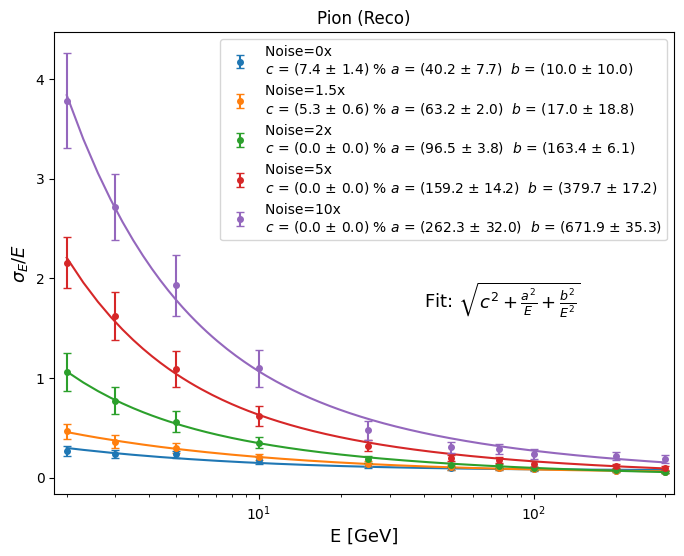

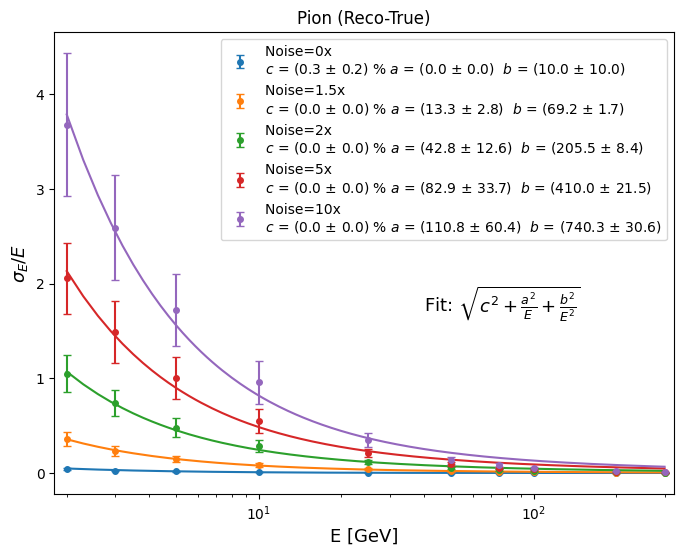

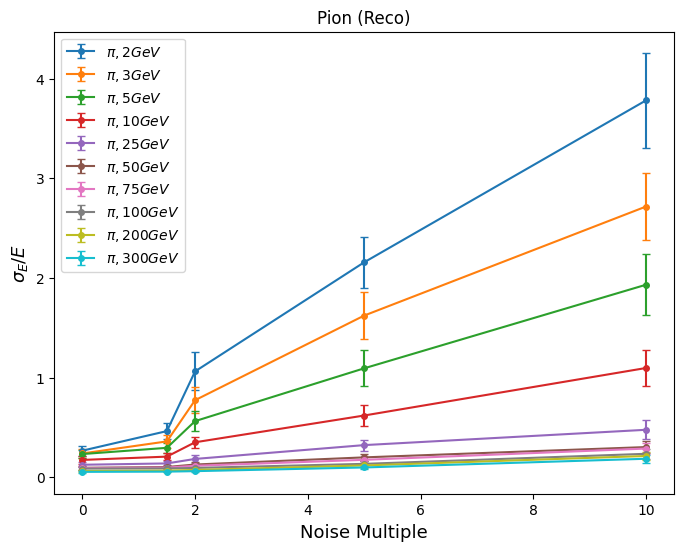

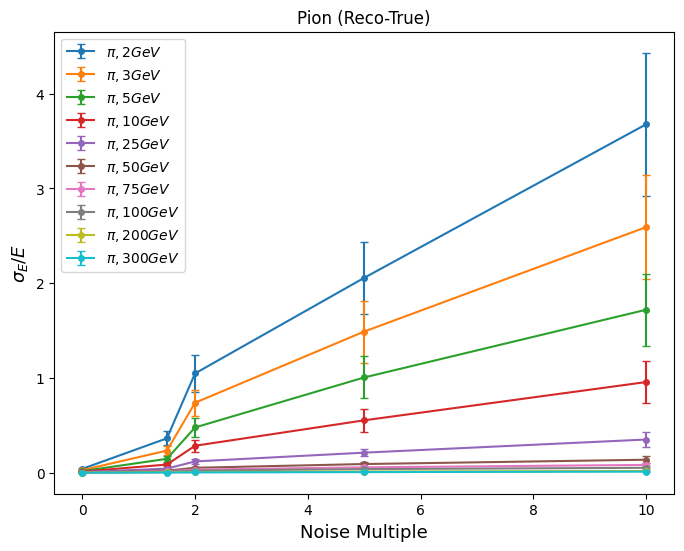

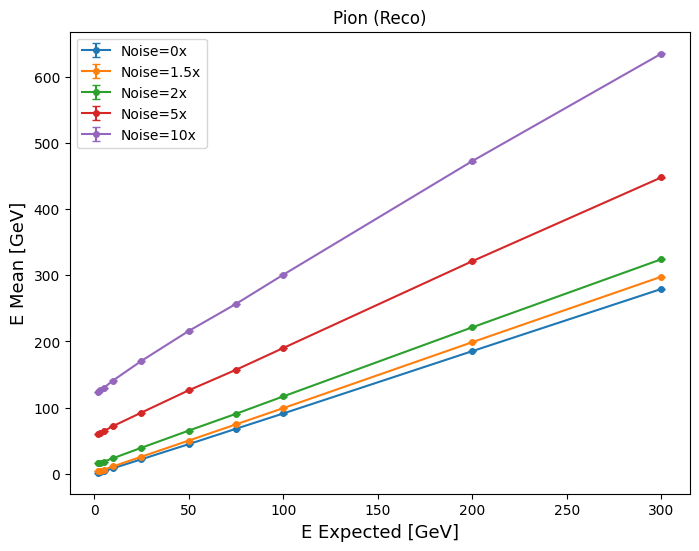

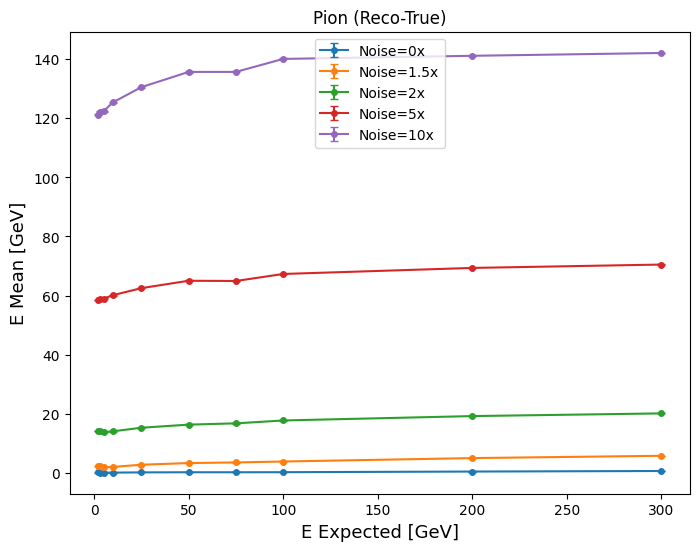

In [81]:
with open("eres_processed/.moddedeRes.pkl",'rb') as file:
    d1 = pickle.load(file)


def plotNoiseSingle(df, energy, species, diff):
    df = df.loc[df["ptdEn"]==energy]
    speciesFormatName = {
        "Gamma": "\gamma",
        "Pion": "\pi",
        "Kaon": "K"
    }
    std = "diff_coeff_std" if diff else "coeff_std"
    std_err = "diff_coeff_std_err" if diff else "coeff_std_err"

    plt.errorbar(df["noise"],df[std]/energy, df[std_err]/energy, fmt='o',markersize=4,linestyle = "-" ,capsize=3,\
                 label=f"${speciesFormatName[species]}, {energy}GeV$")
        #    $c$ = ({ps_1x[0]*100:.1g} $\pm$ {ps_err_1x[0]*100:0.1g}) %      $a$ = ({abs(ps_1x[1])*100:.2g} $\pm$ {ps_err_1x[1]*100:0.1g}) % / "r"$\sqrt{E[GeV]}$
    return

def plotEnergySingle(df,noise,species,diff):
    df = df.loc[df["noise"]==noise]
    
    std = "diff_coeff_std" if diff else "coeff_std"
    std_err = "diff_coeff_std_err" if diff else "coeff_std_err"
    lowerBound = [0,0,0.1]
    ps_1x, ps_cov_1x = curve_fit(fit_energy_resolution_quad,np.asarray(df["ptdEn"]), np.asarray(df[std])/np.asarray(df["ptdEn"]), bounds=(lowerBound,[100,100,100]))
    ps_err_1x = np.sqrt(np.diag(ps_cov_1x))
    for i in range(len(ps_1x)):
        if ps_1x[i]- lowerBound[i] < 10**-10: #Or: floating point error
            ps_err_1x[i] = lowerBound[i]

    container = plt.errorbar(df["ptdEn"],df[std]/df["ptdEn"], df[std_err]/df["ptdEn"], fmt='o',markersize=4,linestyle = "none" ,capsize=3,\
                 label=f"Noise={noise}x \n$c$ = ({ps_1x[0]*100:.1f} $\pm$ {ps_err_1x[0]*100:0.1f}) % $a$ = ({abs(ps_1x[1])*100:.1f} $\pm$ {ps_err_1x[1]*100:0.1f})  $b$ = ({ps_1x[2]*100:.1f} $\pm$ {ps_err_1x[2]*100:.1f})")
    ens = np.asarray(df["ptdEn"])
    x_lin = np.linspace(ens[0],ens[-1],1000)
    colorRepeat = container[0].get_color()
    plt.plot(x_lin,fit_energy_resolution_quad(x_lin,ps_1x[0],ps_1x[1],ps_1x[2]), color=colorRepeat)
    
    return

def plotMeanSingle(df, noise, species, diff):
    df = df.loc[df["noise"]==noise]
    
    mean = "diff_coeff_mean" if diff else "coeff_mean"
    mean_err = "diff_coeff_mean_err" if diff else "coeff_mean_err"

    container = plt.errorbar(df["ptdEn"],df[mean],df[mean_err], fmt='o',markersize=4,linestyle = "-" ,capsize=3,\
                 label=f"Noise={noise}x")
    # ens = np.asarray(df["ptdEn"])
    # x_lin = np.linspace(ens[0],ens[-1],1000)
    # colorRepeat = container[0].get_color()
    # plt.plot(x_lin,fit_energy_resolution_quad(x_lin,ps_1x[0],ps_1x[1],ps_1x[2]), color=colorRepeat)
    return
    


def plotbyNoise(data, species, diff=False):
    data = data.loc[data["species"]==species]

    fig = plt.figure(figsize = [8,6])
    plt.xlabel("Noise Multiple", fontsize=13)
    plt.ylabel(r"$\sigma_E/E$", fontsize=13)
    # plt.xscale("log")
    
    for energy in [2,3,5,10,25,50,75,100,200,300]:
        plotNoiseSingle(data, energy, species, diff)

    titleFormat = f"{species} (Reco-True)" if diff else f"{species} (Reco)"
    plt.title(titleFormat)
    plt.legend()
    return

def plotbyEnergy(data, species, diff=False):
    data = data.loc[data["species"]==species]

    fig = plt.figure(figsize = [8,6])
    plt.xlabel("E [GeV]", fontsize=13)
    plt.ylabel(r"$\sigma_E/E$", fontsize=13)
    plt.xscale("log")
    plt.xlim(1.8,325)
    
    plt.text(40,1.7,r"Fit: $\sqrt{c^2 + \frac{a^2}{E} + \frac{b^2}{E^2}}$", fontsize=13)
    for noise in [0,1.5,2,5,10]:
        plotEnergySingle(data,noise,species,diff)

    titleFormat = f"{species} (Reco-True)" if diff else f"{species} (Reco)"
    plt.title(titleFormat)
    plt.legend()
    return

def plotbyMean(data, species, diff=False):
    data = data.loc[data["species"]==species]

    fig = plt.figure(figsize = [8,6])
    plt.xlabel("E Expected [GeV]", fontsize=13)
    plt.ylabel("E Mean [GeV]", fontsize=13)
    # plt.xscale("log")
    # plt.xlim(1.8,325)
    
    # plt.text(40,1.7,r"Fit: $\sqrt{c^2 + \frac{a^2}{E} + \frac{b^2}{E^2}}$", fontsize=13)
    for noise in [0,1.5,2,5,10]:
        plotMeanSingle(data,noise,species,diff)

    titleFormat = f"{species} (Reco-True)" if diff else f"{species} (Reco)"
    plt.title(titleFormat)
    plt.legend()
    

    return

bepo = "Pion"
plotbyEnergy(d1,bepo, diff=False)
plotbyEnergy(d1,bepo, diff=True)
plotbyNoise(d1,bepo, diff=False)
plotbyNoise(d1,bepo, diff=True)
plotbyMean(d1,bepo,diff=False)
plotbyMean(d1,bepo,diff=True)
